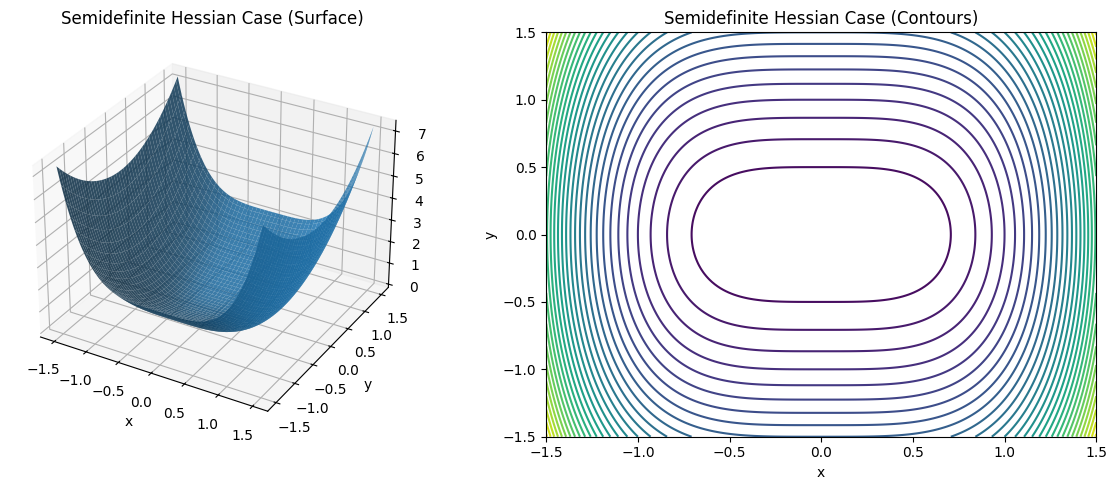

Semidefinite Hessian eigenvalues: [0. 2.]
Eigenvectors:
 [[1. 0.]
 [0. 1.]]


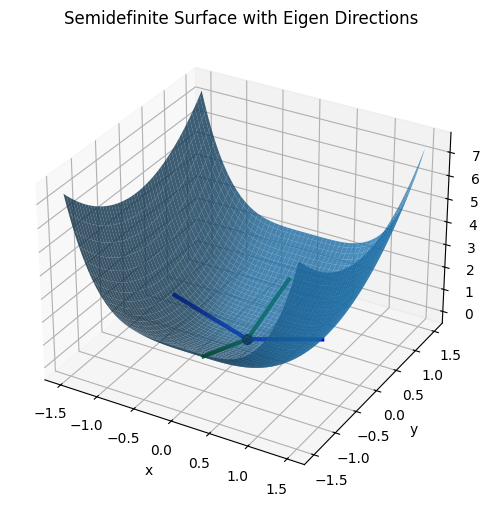

In [2]:
"""
Created on Wed Jan 21 11:04:12 2026

@author: Dr. Vaibhav Kumar
Assistant Professor, DSE, IISERB
"""

import numpy as np
from numpy.linalg import eig
# from common_utils import create_grid, plot_surface_and_contours
import matplotlib.pyplot as plt



def f_semidefinite(x, y):
    """
    Semidefinite Hessian example.

    f(x, y) = x^4 + y^2

    Intuition:
    - Curvature in y-direction is positive.
    - Flat curvature in x-direction at origin.
    - Hessian is positive semidefinite.

    Key idea:
    - Second-order test is inconclusive.
    - Higher-order terms decide optimality.

   Experiment 1: Break convexity slightly
   f(x, y) = x**2 + y**2 + ε*x*y
   ε = 0.1
   ε = 0.5
   ε = 1.2
   Observe
    Small ε → convex
    Large ε → saddle appears
    One eigenvalue becomes negative
   Experiment 2: try a function which is not quadratic f(x, y) = exp(x) + y**2

    Experiment 3: Compare for Convex, Saddle, Semidefinite
    f1 = x**2 + y**2
    f2 = x**4 + y**2
    f3 = x**2 - y**2


    """
    return x**4 + y**2


# ------------------------------------------------------------
# Surface + Contour Visualization
# ------------------------------------------------------------

X, Y = create_grid(-1.5, 1.5, -1.5, 1.5)
Z = f_semidefinite(X, Y)

plot_surface_and_contours(X, Y, Z,
                          "Semidefinite Hessian Case")


# ------------------------------------------------------------
# Hessian Analysis at (0,0)
# ------------------------------------------------------------

H_semi = np.array([[0, 0],
                   [0, 2]])

eigvals, eigvecs = eig(H_semi)

print("Semidefinite Hessian eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)


# ------------------------------------------------------------
# Eigenvector Visualization on Surface
# ------------------------------------------------------------

x0, y0 = 0.0, 0.0
z0 = f_semidefinite(x0, y0)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(X, Y, Z, alpha=0.8)

# Mark stationary point
ax.scatter(x0, y0, z0, color='black', s=50)

scale = 1.0

for i in range(len(eigvals)):
    v = eigvecs[:, i]

    if np.isclose(eigvals[i], 0):
        color = 'blue'
        label = "Flat direction (zero curvature)"
    else:
        color = 'green'
        label = "Positive curvature direction"

    # + direction
    x1 = x0 + scale * v[0]
    y1 = y0 + scale * v[1]
    z1 = f_semidefinite(x1, y1)

    # - direction
    x2 = x0 - scale * v[0]
    y2 = y0 - scale * v[1]
    z2 = f_semidefinite(x2, y2)

    ax.plot([x0, x1], [y0, y1], [z0, z1],
            color=color, linewidth=3)
    ax.plot([x0, x2], [y0, y2], [z0, z2],
            color=color, linewidth=3)

ax.set_title("Semidefinite Surface with Eigen Directions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
plt.show()